In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pingouin as pg
import numpy as np
from scipy import stats
import os
import smarts_cerebellum.globals as gl

In [2]:
CST_T1  = pd.read_csv(os.path.join(gl.baseDir, 'regression', 'summary_MNISymC_T1_slope.tsv'), sep = '\t')   # slope for each subject at L/R CST
CST_GM  = pd.read_csv(os.path.join(gl.baseDir, 'regression', 'summary_MNISymC_GM_slope.tsv'), sep = '\t')   # slope for each subject at L/R CST
CST_WM  = pd.read_csv(os.path.join(gl.baseDir, 'regression', 'summary_MNISymC_WM_slope.tsv'), sep = '\t')   # slope for each subject at L/R CST
CST_CSF = pd.read_csv(os.path.join(gl.baseDir, 'regression', 'summary_MNISymC_CSF_slope.tsv'), sep = '\t')  # slope for each subject at L/R CST

In [3]:
# lesioned side is always right in patients
t1_r_patients = np.array(CST_T1[(CST_T1.isPatient == 1) & (CST_T1.regionname == 'right_CST')]['mean'])
t1_l_patients = np.array(CST_T1[(CST_T1.isPatient == 1) & (CST_T1.regionname == 'left_CST')]['mean'])
t1_bilat_controls = np.array(CST_T1[CST_T1.isPatient == 0]['mean'])


controls_t1 = CST_T1[CST_T1.isPatient == 0]
controls_bilat_t1 = controls_t1.groupby('subj_id').agg({'mean': 'mean'}).reset_index()
controls_bilat_t1['regionname'] = 'bilat_CST'
controls_bilat_t1['isPatient'] = 0

patients_t1 = CST_T1[(CST_T1.isPatient == 1) & (CST_T1.regionname.isin(['left_CST', 'right_CST']))]

cst_t1 = pd.concat([patients_t1, controls_bilat_t1], ignore_index=True)

**t-test for CST: lesion side in patients, controls** 
 t-value: -0.9792804110360508 	 p-value: 0.3316532451976605


**t-test for CST: non-lesion side in patients, controls** 
 t-value: 0.38182528632486457 	 p-value: 0.7040360432901659


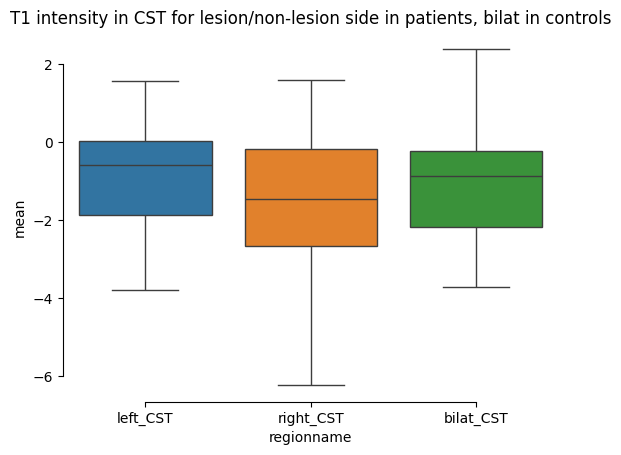

In [4]:
t_val, p_val = stats.ttest_ind(t1_r_patients, t1_bilat_controls)
print(f'**t-test for CST: lesion side in patients, controls** \n t-value: {t_val} \t p-value: {p_val}')
print('\n')

t_val, p_val = stats.ttest_ind(t1_l_patients, t1_bilat_controls)
print(f'**t-test for CST: non-lesion side in patients, controls** \n t-value: {t_val} \t p-value: {p_val}')


fig, ax = plt.subplots()
sns.boxplot(data=cst_t1, x='regionname', y='mean', hue = 'regionname', showfliers=False)

sns.despine(trim = True)
plt.title('T1 intensity in CST for lesion/non-lesion side in patients, bilat in controls')
plt.show()

# ONLY PROBABILITIES NOT MODUALTED VOLUME (for tissue)

In [5]:
# lesioned side is always right in patients
wm_r_patients = np.array(CST_WM[(CST_WM.isPatient == 1) & (CST_WM.regionname == 'right_CST')]['mean'])
wm_l_patients = np.array(CST_WM[(CST_WM.isPatient == 1) & (CST_WM.regionname == 'left_CST')]['mean'])
wm_bilat_controls = np.array(CST_WM[CST_WM.isPatient == 0]['mean'])


controls_wm = CST_WM[CST_WM.isPatient == 0]
controls_bilat_wm = controls_wm.groupby('subj_id').agg({'mean': 'mean'}).reset_index()
controls_bilat_wm['regionname'] = 'bilat_CST'
controls_bilat_wm['isPatient'] = 0

patients_wm = CST_WM[(CST_WM.isPatient == 1) & (CST_WM.regionname.isin(['left_CST', 'right_CST']))]

cst_wm = pd.concat([patients_wm, controls_bilat_wm], ignore_index=True)

**t-test for CST: lesion side in patients, controls** 
 t-value: -2.958923014660687 	 p-value: 0.0045171180892327025


**t-test for CST: non-lesion side in patients, controls** 
 t-value: -1.5312649499496689 	 p-value: 0.13133397174688655


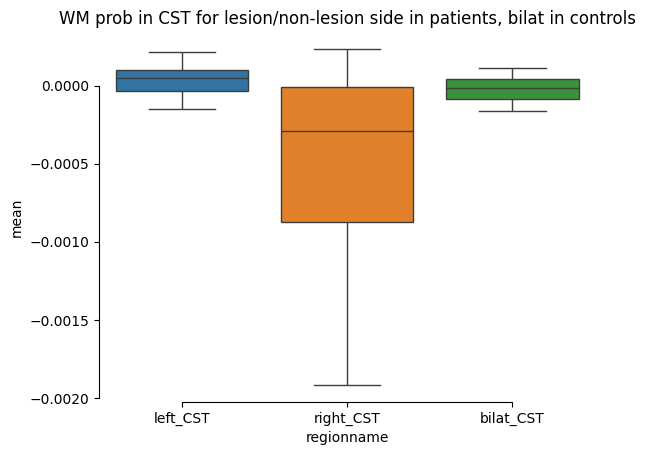

In [6]:
t_val, p_val = stats.ttest_ind(wm_r_patients, wm_bilat_controls)
print(f'**t-test for CST: lesion side in patients, controls** \n t-value: {t_val} \t p-value: {p_val}')
print('\n')

t_val, p_val = stats.ttest_ind(wm_l_patients, wm_bilat_controls)
print(f'**t-test for CST: non-lesion side in patients, controls** \n t-value: {t_val} \t p-value: {p_val}')


fig, ax = plt.subplots()
sns.boxplot(data=cst_wm, x='regionname', y='mean', hue = 'regionname', showfliers=False)

sns.despine(trim = True)
plt.title('WM prob in CST for lesion/non-lesion side in patients, bilat in controls')
plt.show()

In [7]:
# lesioned side is always right in patients
csf_r_patients = np.array(CST_CSF[(CST_CSF.isPatient == 1) & (CST_CSF.regionname == 'right_CST')]['mean'])
csf_l_patients = np.array(CST_CSF[(CST_CSF.isPatient == 1) & (CST_CSF.regionname == 'left_CST')]['mean'])
csf_biat_controls = np.array(CST_CSF[CST_CSF.isPatient == 0]['mean'])


controls_csf = CST_CSF[CST_CSF.isPatient == 0]
controls_bilat_csf = controls_csf.groupby('subj_id').agg({'mean': 'mean'}).reset_index()
controls_bilat_csf['regionname'] = 'bilat_CST'
controls_bilat_csf['isPatient'] = 0

patients_csf = CST_CSF[(CST_CSF.isPatient == 1) & (CST_CSF.regionname.isin(['left_CST', 'right_CST']))]

cst_csf = pd.concat([patients_csf, controls_bilat_csf], ignore_index=True)

**t-test for CST: lesion side in patients, controls** 
 t-value: -0.5921635555676156 	 p-value: 0.5561245137459085


**t-test for CST: non-lesion side in patients, controls** 
 t-value: -1.8156061083692279 	 p-value: 0.07478615619778538


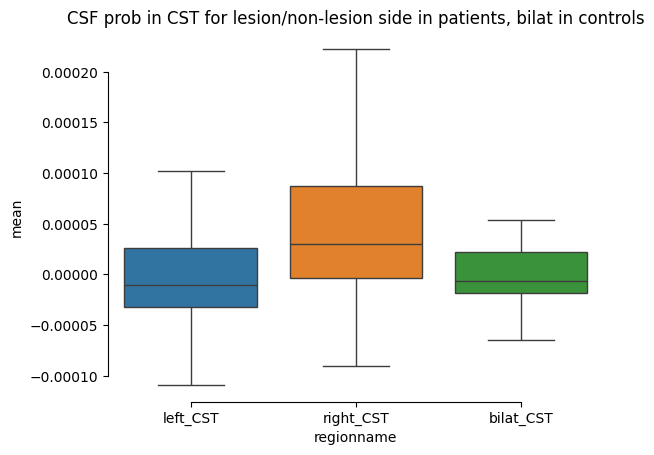

In [8]:
t_val, p_val = stats.ttest_ind(csf_r_patients, csf_biat_controls)
print(f'**t-test for CST: lesion side in patients, controls** \n t-value: {t_val} \t p-value: {p_val}')
print('\n')

t_val, p_val = stats.ttest_ind(csf_l_patients, csf_biat_controls)
print(f'**t-test for CST: non-lesion side in patients, controls** \n t-value: {t_val} \t p-value: {p_val}')


fig, ax = plt.subplots()
sns.boxplot(data=cst_csf, x='regionname', y='mean', hue = 'regionname', showfliers=False)

sns.despine(trim = True)
plt.title('CSF prob in CST for lesion/non-lesion side in patients, bilat in controls')
plt.show()